# Drone Detection - Inference Demo

This notebook demonstrates how to use the trained YOLOv8 model for drone detection.

In [1]:
import sys
sys.path.append('..')

from ultralytics import YOLO
from PIL import Image
import matplotlib.pyplot as plt
from pathlib import Path

## Load Model

Load your trained model checkpoint:

In [2]:
# Path to your trained model
model_path = "../models/checkpoints/drone_detection/weights/best.pt"

# Load model
model = YOLO(model_path)
print(f"Model loaded from: {model_path}")
print(f"Classes: {model.names}")

Model loaded from: ../models/checkpoints/drone_detection/weights/best.pt
Classes: {0: 'drone', 1: 'not-drone'}


## Run Inference on Test Images

In [3]:
# Get some test images from checkpoints (since we don't have the full dataset)
import glob
test_images = glob.glob("../models/checkpoints/*/val_batch*.jpg")[:5]

if not test_images:
    print("No validation images found in checkpoints")
    print("To use the full dataset, run:")
    print("  1. Set ROBOFLOW_API_KEY in .env")
    print("  2. python src/data/collection.py")
    print("  3. python src/data/filter_class.py")
else:
    print(f"Found {len(test_images)} test images from checkpoints")
    for img in test_images:
        print(f"  - {img}")

Found 5 test images from checkpoints
  - ../models/checkpoints/drone_detection_minimal/val_batch1_labels.jpg
  - ../models/checkpoints/drone_detection_minimal/val_batch2_pred.jpg
  - ../models/checkpoints/drone_detection_minimal/val_batch0_labels.jpg
  - ../models/checkpoints/drone_detection_minimal/val_batch1_pred.jpg
  - ../models/checkpoints/drone_detection_minimal/val_batch0_pred.jpg


0: 416x640 3 drones, 21.2ms
1: 416x640 2 not-drones, 21.2ms
2: 416x640 2 drones, 21.2ms
3: 416x640 2 drones, 21.2ms
4: 416x640 (no detections), 21.2ms


Speed: 1.9ms preprocess, 21.2ms inference, 0.5ms postprocess per image at shape (1, 3, 416, 640)


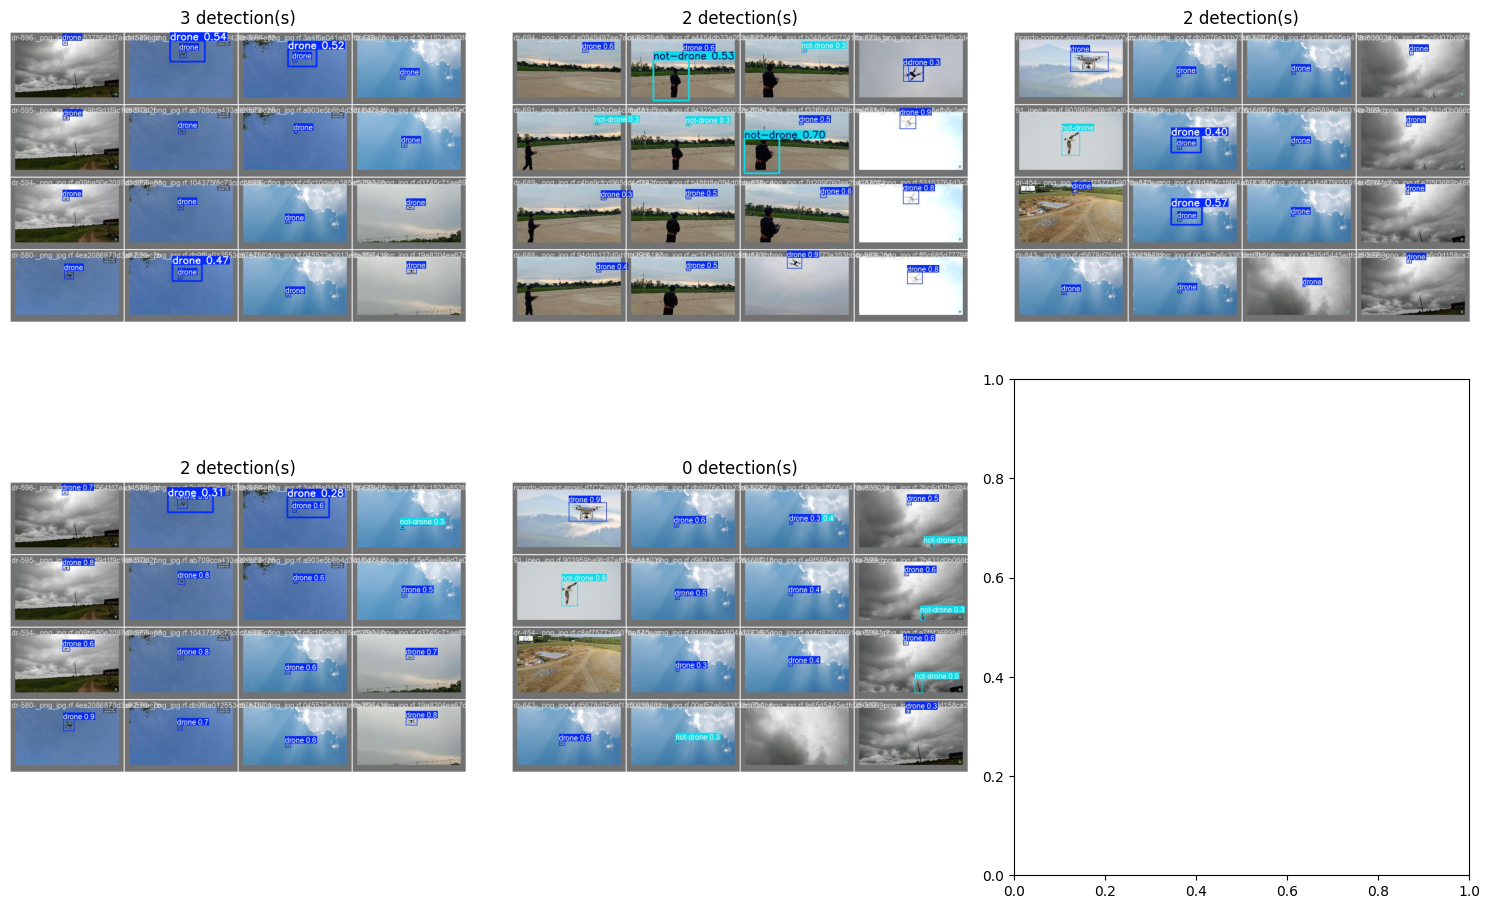

In [4]:
# Run inference
results = model.predict(test_images, conf=0.25)

# Display results
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.flatten()

for i, (result, ax) in enumerate(zip(results, axes)):
    if i >= len(results):
        ax.axis('off')
        continue
    
    # Get annotated image
    img = result.plot()
    
    # Convert BGR to RGB
    img = img[:, :, ::-1]
    
    # Display
    ax.imshow(img)
    ax.axis('off')
    
    # Add detection info
    detections = len(result.boxes)
    ax.set_title(f"{detections} detection(s)", fontsize=12)

plt.tight_layout()
plt.show()

## Detailed Detection Info

In [5]:
# Show detailed info for first result
result = results[0]

print(f"Image: {result.path}")
print(f"Image size: {result.orig_shape}")
print(f"\nDetections: {len(result.boxes)}\n")

for i, box in enumerate(result.boxes):
    cls = int(box.cls[0])
    conf = float(box.conf[0])
    xyxy = box.xyxy[0].cpu().numpy()
    class_name = model.names[cls]
    
    print(f"Detection {i+1}:")
    print(f"  Class: {class_name}")
    print(f"  Confidence: {conf:.2%}")
    print(f"  Bounding Box: [{xyxy[0]:.1f}, {xyxy[1]:.1f}, {xyxy[2]:.1f}, {xyxy[3]:.1f}]")
    print(f"  Center: ({(xyxy[0]+xyxy[2])/2:.1f}, {(xyxy[1]+xyxy[3])/2:.1f})")
    print(f"  Size: {xyxy[2]-xyxy[0]:.1f} x {xyxy[3]-xyxy[1]:.1f}")
    print()

Image: ../models/checkpoints/drone_detection_minimal/val_batch1_labels.jpg
Image size: (896, 1408)

Detections: 3

Detection 1:
  Class: drone
  Confidence: 53.56%
  Bounding Box: [494.5, 26.1, 601.2, 91.8]
  Center: (547.9, 58.9)
  Size: 106.7 x 65.7

Detection 2:
  Class: drone
  Confidence: 51.65%
  Bounding Box: [858.1, 53.2, 946.1, 106.1]
  Center: (902.1, 79.6)
  Size: 88.0 x 53.0

Detection 3:
  Class: drone
  Confidence: 47.46%
  Bounding Box: [501.7, 717.1, 592.9, 770.0]
  Center: (547.3, 743.5)
  Size: 91.2 x 52.9



## Run on Custom Image

In [6]:
# NOTE: This cell is for custom images - replace the path with your own image
# Skipping execution as this is just a template
# Uncomment and modify the path below to use:

# custom_image = "path/to/your/image.jpg"
# result = model.predict(custom_image, conf=0.25)[0]
# img = result.plot()
# img = img[:, :, ::-1]  # BGR to RGB
# plt.figure(figsize=(12, 8))
# plt.imshow(img)
# plt.axis('off')
# plt.title(f"Detected {len(result.boxes)} object(s)")
# plt.show()
# for box in result.boxes:
#     cls = int(box.cls[0])
#     conf = float(box.conf[0])
#     class_name = model.names[cls]
#     print(f"{class_name}: {conf:.2%} confidence")

print("⚠️  Skipped: Replace path with your own image to use this cell")

⚠️  Skipped: Replace path with your own image to use this cell


## Save Results

In [7]:
# Save annotated images
output_dir = Path("../results/demo_predictions")
output_dir.mkdir(parents=True, exist_ok=True)

results = model.predict(test_images, save=True, project=str(output_dir.parent), name=output_dir.name)

print(f"✓ Results saved to: {output_dir}")

0: 416x640 3 drones, 16.4ms
1: 416x640 2 not-drones, 16.4ms
2: 416x640 2 drones, 16.4ms
3: 416x640 2 drones, 16.4ms
4: 416x640 (no detections), 16.4ms


Speed: 1.0ms preprocess, 16.4ms inference, 0.2ms postprocess per image at shape (1, 3, 416, 640)


Results saved to /Users/ogorpynich/omnivision/results/demo_predictions2


✓ Results saved to: ../results/demo_predictions
